# UNIQUE input data preparation: MDR1

---

The process of preparing MDR1 input datasets to run UNIQUE Pipeline includes the following steps:
- Importing the preprocessed MDR1 dataset.
- Integrating predictions from Chemprop and corresponding uncertainty estimates (ensemble variance).
- Adding and scaling GNN latent fingerprints.

In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np

## Load MDR1 data

In [2]:
df = pd.read_csv('data/MDR1_dataset_with_splits.csv', index_col=0)
df.head()

,Id,Structure,mol,MDCK-MDR1_LogER,Subset,split
0,Mol1,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,<rdkit.Chem.rdchem.Mol object at 0x7744711fb760>,1.493167,Training,train
1,Mol2,CCOc1cc2nn(CCC(C)(C)O)cc2cc1NC(=O)c1cccc(C(F)F)n1,<rdkit.Chem.rdchem.Mol object at 0x7744711fb6f0>,1.040780,Training,val
2,Mol5,CC(C)(O)CCn1cc2cc(NC(=O)c3cccc(C(F)(F)F)n3)c(C...,<rdkit.Chem.rdchem.Mol object at 0x7744711fb990>,1.010597,Training,val
3,Mol6,CC#CC(=O)N[C@H]1CCCN(c2c(F)cc(C(N)=O)c3[nH]c(C...,<rdkit.Chem.rdchem.Mol object at 0x7744711fba00>,0.860626,Training,train
4,Mol10,CC(C)NC(=O)COc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3...,<rdkit.Chem.rdchem.Mol object at 0x7744711fbbc0>,1.301829,Training,val


In [3]:
df['which_set'] = df['Subset'].copy()
df['which_set'] = df['which_set'].replace({'Training':'TRAIN', 'Calibration':'CALIBRATION', 'Validation':'TEST'})
df['which_set'].value_counts()

which_set
TRAIN          1321
CALIBRATION     791
TEST            527
Name: count, dtype: int64

Select columns

In [4]:
df = df[['Id','Structure','MDCK-MDR1_LogER','which_set']]
df.head()

,Id,Structure,MDCK-MDR1_LogER,which_set
0,Mol1,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,1.493167,TRAIN
1,Mol2,CCOc1cc2nn(CCC(C)(C)O)cc2cc1NC(=O)c1cccc(C(F)F)n1,1.040780,TRAIN
2,Mol5,CC(C)(O)CCn1cc2cc(NC(=O)c3cccc(C(F)(F)F)n3)c(C...,1.010597,TRAIN
3,Mol6,CC#CC(=O)N[C@H]1CCCN(c2c(F)cc(C(N)=O)c3[nH]c(C...,0.860626,TRAIN
4,Mol10,CC(C)NC(=O)COc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3...,1.301829,TRAIN


## Read model predictions

In [5]:
df_preds = pd.read_csv('MDR1_model/predictions.csv')
df_preds.head()

,Unnamed: 0,Id,Structure,mol,MDCK-MDR1_LogER,Subset,split,MDCK-MDR1_LogER_unc
0,0,Mol1,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,<rdkit.Chem.rdchem.Mol object at 0x7744711fb760>,1.246462,Training,train,0.003577
1,1,Mol2,CCOc1cc2nn(CCC(C)(C)O)cc2cc1NC(=O)c1cccc(C(F)F)n1,<rdkit.Chem.rdchem.Mol object at 0x7744711fb6f0>,0.729273,Training,val,0.005464
2,2,Mol5,CC(C)(O)CCn1cc2cc(NC(=O)c3cccc(C(F)(F)F)n3)c(C...,<rdkit.Chem.rdchem.Mol object at 0x7744711fb990>,0.904649,Training,val,0.015962
3,3,Mol6,CC#CC(=O)N[C@H]1CCCN(c2c(F)cc(C(N)=O)c3[nH]c(C...,<rdkit.Chem.rdchem.Mol object at 0x7744711fba00>,1.248326,Training,train,0.001152
4,4,Mol10,CC(C)NC(=O)COc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3...,<rdkit.Chem.rdchem.Mol object at 0x7744711fbbc0>,1.059820,Training,val,0.004739


In [6]:
all([df.Id.iloc[x] == df_preds.Id.iloc[x] for x in range(df.shape[0])])

True

Rename columns

In [7]:
df_preds = df_preds.rename(columns={"MDCK-MDR1_LogER": "predicted MDCK-MDR1_LogER", "MDCK-MDR1_LogER_unc": "variance MDCK-MDR1_LogER"})

Select columns

In [8]:
df_preds = df_preds[['Id','predicted MDCK-MDR1_LogER','variance MDCK-MDR1_LogER']]
df_preds.head()

,Id,predicted MDCK-MDR1_LogER,variance MDCK-MDR1_LogER
0,Mol1,1.246462,0.003577
1,Mol2,0.729273,0.005464
2,Mol5,0.904649,0.015962
3,Mol6,1.248326,0.001152
4,Mol10,1.059820,0.004739


Merge predictions data

In [9]:
print(df.shape)
print(df_preds.shape)
df = df.merge(df_preds, on=['Id'])
print(df.shape)
df.head()

(2639, 4)
(2639, 3)
(2639, 6)


,Id,Structure,MDCK-MDR1_LogER,which_set,predicted MDCK-MDR1_LogER,variance MDCK-MDR1_LogER
0,Mol1,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,1.493167,TRAIN,1.246462,0.003577
1,Mol2,CCOc1cc2nn(CCC(C)(C)O)cc2cc1NC(=O)c1cccc(C(F)F)n1,1.040780,TRAIN,0.729273,0.005464
2,Mol5,CC(C)(O)CCn1cc2cc(NC(=O)c3cccc(C(F)(F)F)n3)c(C...,1.010597,TRAIN,0.904649,0.015962
3,Mol6,CC#CC(=O)N[C@H]1CCCN(c2c(F)cc(C(N)=O)c3[nH]c(C...,0.860626,TRAIN,1.248326,0.001152
4,Mol10,CC(C)NC(=O)COc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3...,1.301829,TRAIN,1.059820,0.004739


## Read GNN latent representations

In [10]:
df_latent = pd.read_csv('MDR1_model/latent_fps_0.csv')
df_latent.head()

,fp_0,fp_1,fp_2,fp_3,fp_4,fp_5,fp_6,fp_7,fp_8,fp_9,fp_10,fp_11,fp_12,fp_13,fp_14,fp_15,fp_16,fp_17,fp_18,fp_19,fp_20,fp_21,fp_22,fp_23,fp_24,fp_25,fp_26,fp_27,fp_28,fp_29,fp_30,fp_31,fp_32,fp_33,fp_34,fp_35,fp_36,fp_37,fp_38,fp_39,fp_40,fp_41,fp_42,fp_43,fp_44,fp_45,fp_46,fp_47,fp_48,fp_49,fp_50,fp_51,fp_52,fp_53,fp_54,fp_55,fp_56,fp_57,fp_58,fp_59,fp_60,fp_61,fp_62,fp_63,fp_64,fp_65,fp_66,fp_67,fp_68,fp_69,fp_70,fp_71,fp_72,fp_73,fp_74,fp_75,fp_76,fp_77,fp_78,fp_79,fp_80,fp_81,fp_82,fp_83,fp_84,fp_85,fp_86,fp_87,fp_88,fp_89,fp_90,fp_91,fp_92,fp_93,fp_94,fp_95,fp_96,fp_97,fp_98,fp_99,fp_100,fp_101,fp_102,fp_103,fp_104,fp_105,fp_106,fp_107,fp_108,fp_109,fp_110,fp_111,fp_112,fp_113,fp_114,fp_115,fp_116,fp_117,fp_118,fp_119,fp_120,fp_121,fp_122,fp_123,fp_124,fp_125,fp_126,fp_127,fp_128,fp_129,fp_130,fp_131,fp_132,fp_133,fp_134,fp_135,fp_136,fp_137,fp_138,fp_139,fp_140,fp_141,fp_142,fp_143,fp_144,fp_145,fp_146,fp_147,fp_148,fp_149,fp_150,fp_151,fp_152,fp_153,fp_154,fp_155,fp_156,fp_157,fp_158,fp_159,fp_160,fp_161,fp_162,fp_163,fp_164,fp_165,fp_166,fp_167,fp_168,fp_169,fp_170,fp_171,fp_172,fp_173,fp_174,fp_175,fp_176,fp_177,fp_178,fp_179,fp_180,fp_181,fp_182,fp_183,fp_184,fp_185,fp_186,fp_187,fp_188,fp_189,fp_190,fp_191,fp_192,fp_193,fp_194,fp_195,fp_196,fp_197,fp_198,fp_199,fp_200,fp_201,fp_202,fp_203,fp_204,fp_205,fp_206,fp_207,fp_208,fp_209,fp_210,fp_211,fp_212,fp_213,fp_214,fp_215,fp_216,fp_217,fp_218,fp_219,fp_220,fp_221,fp_222,fp_223,fp_224,fp_225,fp_226,fp_227,fp_228,fp_229,fp_230,fp_231,fp_232,fp_233,fp_234,fp_235,fp_236,fp_237,fp_238,fp_239,fp_240,fp_241,fp_242,fp_243,fp_244,fp_245,fp_246,fp_247,fp_248,fp_249,fp_250,fp_251,fp_252,fp_253,fp_254,fp_255,fp_256,fp_257,fp_258,fp_259,fp_260,fp_261,fp_262,fp_263,fp_264,fp_265,fp_266,fp_267,fp_268,fp_269,fp_270,fp_271,fp_272,fp_273,fp_274,fp_275,fp_276,fp_277,fp_278,fp_279,fp_280,fp_281,fp_282,fp_283,fp_284,fp_285,fp_286,fp_287,fp_288,fp_289,fp_290,fp_291,fp_292,fp_293,fp_294,fp_295,fp_296,fp_297,fp_298,fp_299
0,0.0,0.022473,0.347611,0.048903,0.000646,0.022884,0.028259,0.037229,0.0,0.000000,0.014828,0.009977,0.041324,0.000139,0.007389,0.117769,0.196595,0.0,0.225198,0.095292,0.069374,0.143737,0.044455,0.010242,0.007673,0.038757,0.025289,0.102052,0.010394,0.002329,0.212633,0.079810,0.0,0.0,0.000000,0.000000,0.008273,0.241815,0.002917,0.171164,0.015563,0.131039,0.033214,0.0,0.0,0.0,0.029910,0.246105,0.000000,0.239741,0.005506,0.0,0.000305,0.0008,0.000000,0.180058,0.005665,0.214552,0.005076,0.004781,0.010475,0.005282,0.0,0.005574,0.127576,0.022550,0.006638,0.000000,0.050207,0.013349,0.000000,0.0,0.000000,0.0,0.000898,0.000000,0.0,0.212196,0.010130,0.267572,0.000000,0.124251,0.064367,0.0,0.0,0.002901,0.0,0.0,0.152697,0.021169,0.0,0.287879,0.037817,0.032448,0.0,0.0,0.000000,0.000000,0.140172,0.029623,0.063683,0.005660,0.001396,0.036072,0.212494,0.0,0.160597,0.002201,0.010938,0.217346,0.000000,0.222903,0.122754,0.045966,0.288143,0.284558,0.0,0.0,0.005403,0.003943,0.000000,0.188143,0.000000,0.149727,0.000000,0.000000,0.0,0.137230,0.069331,0.003933,0.039557,0.084335,0.176203,0.040613,0.0,0.007487,0.010127,0.143363,0.000000,0.009778,0.108469,0.001859,0.035543,0.047316,0.098089,0.001333,0.013507,0.085351,0.0,0.0,0.0,0.0,0.035644,0.221539,0.007874,0.061820,0.018984,0.048519,0.056822,0.006210,0.010594,0.056524,0.222332,0.172845,0.000000,0.050245,0.182276,0.0,0.014043,0.117512,0.000000,0.143289,0.121623,0.187593,0.17447,0.0,0.0,0.202170,0.012470,0.211305,0.0,0.0,0.173455,0.001942,0.021481,0.0,0.0,0.073686,0.211951,0.201260,0.005674,0.004129,0.0,0.002826,0.025151,0.010395,0.0,0.0,0.011943,0.145293,0.018114,0.0,0.011546,0.066758,0.024113,0.192240,0.0,0.0,0.002243,0.000000,0.060141,0.0,0.131601,0.047901,0.0,0.000000,0.000000,0.0,0.002167,0.000000,0.000000,0.0,0.142240,0.0,0.266963,0.019853,0.010586,0.023013,0.0,0.012706,0.079367,0.000000,0.147028,0.014567,0.006120,0.009695,0.102405,0.0,0.0,0.0,0.156147,0.0,0.030376,0.0,0.243909,0.059531,0.0,0.267948,0.187695,0.155958,0.174640,0.005534,0.169147,0.0

Add SMILES data

In [11]:
original_data = pd.read_csv('data/MDR1_dataset_with_splits.csv', index_col=0)
smiles = original_data['Structure']
smiles

0       CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...
1       CCOc1cc2nn(CCC(C)(C)O)cc2cc1NC(=O)c1cccc(C(F)F)n1
2       CC(C)(O)CCn1cc2cc(NC(=O)c3cccc(C(F)(F)F)n3)c(C...
3       CC#CC(=O)N[C@H]1CCCN(c2c(F)cc(C(N)=O)c3[nH]c(C...
4       CC(C)NC(=O)COc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3...
                              ...                        
2634    Cc1ccc(Nc2nccc(N(C)c3ccc4c(C)n(C)nc4c3)n2)cc1S...
2635                              O=C(NNc1ccccc1)c1ccncc1
2636    CN(C)C(=O)C(CCN1CCC(O)(c2ccc(Cl)cc2)CC1)(c1ccc...
2637    COc1cc2c(cc1OC)CN(C(=O)C1CCCN(C(=O)c3ccc(Cl)cc...
2638              O=C(c1ccc2c(c1)CCCC2)N1CCOCC1c1ccn[nH]1
Name: Structure, Length: 2639, dtype: object

In [12]:
print(df_latent.shape)
print(smiles.shape)
df_latent = pd.concat([smiles, df_latent], axis=1)
print(df_latent.shape)
df_latent.head()

(2639, 300)
(2639,)
(2639, 301)


,Structure,fp_0,fp_1,fp_2,fp_3,fp_4,fp_5,fp_6,fp_7,fp_8,fp_9,fp_10,fp_11,fp_12,fp_13,fp_14,fp_15,fp_16,fp_17,fp_18,fp_19,fp_20,fp_21,fp_22,fp_23,fp_24,fp_25,fp_26,fp_27,fp_28,fp_29,fp_30,fp_31,fp_32,fp_33,fp_34,fp_35,fp_36,fp_37,fp_38,fp_39,fp_40,fp_41,fp_42,fp_43,fp_44,fp_45,fp_46,fp_47,fp_48,fp_49,fp_50,fp_51,fp_52,fp_53,fp_54,fp_55,fp_56,fp_57,fp_58,fp_59,fp_60,fp_61,fp_62,fp_63,fp_64,fp_65,fp_66,fp_67,fp_68,fp_69,fp_70,fp_71,fp_72,fp_73,fp_74,fp_75,fp_76,fp_77,fp_78,fp_79,fp_80,fp_81,fp_82,fp_83,fp_84,fp_85,fp_86,fp_87,fp_88,fp_89,fp_90,fp_91,fp_92,fp_93,fp_94,fp_95,fp_96,fp_97,fp_98,fp_99,fp_100,fp_101,fp_102,fp_103,fp_104,fp_105,fp_106,fp_107,fp_108,fp_109,fp_110,fp_111,fp_112,fp_113,fp_114,fp_115,fp_116,fp_117,fp_118,fp_119,fp_120,fp_121,fp_122,fp_123,fp_124,fp_125,fp_126,fp_127,fp_128,fp_129,fp_130,fp_131,fp_132,fp_133,fp_134,fp_135,fp_136,fp_137,fp_138,fp_139,fp_140,fp_141,fp_142,fp_143,fp_144,fp_145,fp_146,fp_147,fp_148,fp_149,fp_150,fp_151,fp_152,fp_153,fp_154,fp_155,fp_156,fp_157,fp_158,fp_159,fp_160,fp_161,fp_162,fp_163,fp_164,fp_165,fp_166,fp_167,fp_168,fp_169,fp_170,fp_171,fp_172,fp_173,fp_174,fp_175,fp_176,fp_177,fp_178,fp_179,fp_180,fp_181,fp_182,fp_183,fp_184,fp_185,fp_186,fp_187,fp_188,fp_189,fp_190,fp_191,fp_192,fp_193,fp_194,fp_195,fp_196,fp_197,fp_198,fp_199,fp_200,fp_201,fp_202,fp_203,fp_204,fp_205,fp_206,fp_207,fp_208,fp_209,fp_210,fp_211,fp_212,fp_213,fp_214,fp_215,fp_216,fp_217,fp_218,fp_219,fp_220,fp_221,fp_222,fp_223,fp_224,fp_225,fp_226,fp_227,fp_228,fp_229,fp_230,fp_231,fp_232,fp_233,fp_234,fp_235,fp_236,fp_237,fp_238,fp_239,fp_240,fp_241,fp_242,fp_243,fp_244,fp_245,fp_246,fp_247,fp_248,fp_249,fp_250,fp_251,fp_252,fp_253,fp_254,fp_255,fp_256,fp_257,fp_258,fp_259,fp_260,fp_261,fp_262,fp_263,fp_264,fp_265,fp_266,fp_267,fp_268,fp_269,fp_270,fp_271,fp_272,fp_273,fp_274,fp_275,fp_276,fp_277,fp_278,fp_279,fp_280,fp_281,fp_282,fp_283,fp_284,fp_285,fp_286,fp_287,fp_288,fp_289,fp_290,fp_291,fp_292,fp_293,fp_294,fp_295,fp_296,fp_297,fp_298,fp_299
0,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,0.0,0.022473,0.347611,0.048903,0.000646,0.022884,0.028259,0.037229,0.0,0.000000,0.014828,0.009977,0.041324,0.000139,0.007389,0.117769,0.196595,0.0,0.225198,0.095292,0.069374,0.143737,0.044455,0.010242,0.007673,0.038757,0.025289,0.102052,0.010394,0.002329,0.212633,0.079810,0.0,0.0,0.000000,0.000000,0.008273,0.241815,0.002917,0.171164,0.015563,0.131039,0.033214,0.0,0.0,0.0,0.029910,0.246105,0.000000,0.239741,0.005506,0.0,0.000305,0.0008,0.000000,0.180058,0.005665,0.214552,0.005076,0.004781,0.010475,0.005282,0.0,0.005574,0.127576,0.022550,0.006638,0.000000,0.050207,0.013349,0.000000,0.0,0.000000,0.0,0.000898,0.000000,0.0,0.212196,0.010130,0.267572,0.000000,0.124251,0.064367,0.0,0.0,0.002901,0.0,0.0,0.152697,0.021169,0.0,0.287879,0.037817,0.032448,0.0,0.0,0.000000,0.000000,0.140172,0.029623,0.063683,0.005660,0.001396,0.036072,0.212494,0.0,0.160597,0.002201,0.010938,0.217346,0.000000,0.222903,0.122754,0.045966,0.288143,0.284558,0.0,0.0,0.005403,0.003943,0.000000,0.188143,0.000000,0.149727,0.000000,0.000000,0.0,0.137230,0.069331,0.003933,0.039557,0.084335,0.176203,0.040613,0.0,0.007487,0.010127,0.143363,0.000000,0.009778,0.108469,0.001859,0.035543,0.047316,0.098089,0.001333,0.013507,0.085351,0.0,0.0,0.0,0.0,0.035644,0.221539,0.007874,0.061820,0.018984,0.048519,0.056822,0.006210,0.010594,0.056524,0.222332,0.172845,0.000000,0.050245,0.182276,0.0,0.014043,0.117512,0.000000,0.143289,0.121623,0.187593,0.17447,0.0,0.0,0.202170,0.012470,0.211305,0.0,0.0,0.173455,0.001942,0.021481,0.0,0.0,0.073686,0.211951,0.201260,0.005674,0.004129,0.0,0.002826,0.025151,0.010395,0.0,0.0,0.011943,0.145293,0.018114,0.0,0.011546,0.066758,0.024113,0.192240,0.0,0.0,0.002243,0.000000,0.060141,0.0,0.131601,0.047901,0.0,0.000000,0.000000,0.0,0.002167,0.000000,0.000000,0.0,0.142240,0.0,0.266963,0.019853,0.010586,0.023013,0.0,0.012706,0.079367,0.000000,0.147028,0.014567,0.006120,0.009695,0.102405,0.0,0.0,0.0,0.156147,0.0,0.030376,0.0,0.243909,0.059531,0

In [13]:
# Drop duplicated latent profiles
df_latent = df_latent.drop_duplicates()
df_latent.shape

(2639, 301)

Inspect feature distributions and outlier identification

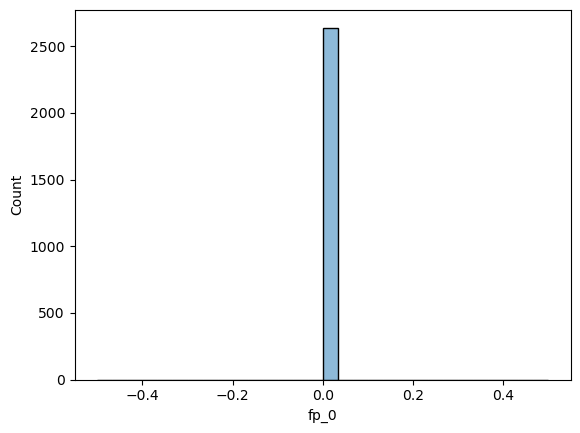

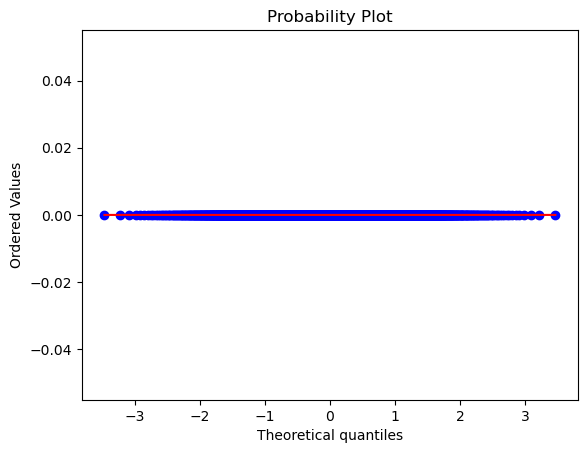

In [14]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

# inspect the first latent feature
feature = df_latent['fp_0']
# histogram
sns.histplot(feature, kde=True, bins=30)
plt.show()
# Q-Q plot
stats.probplot(feature, dist="norm", plot=plt)
plt.show()

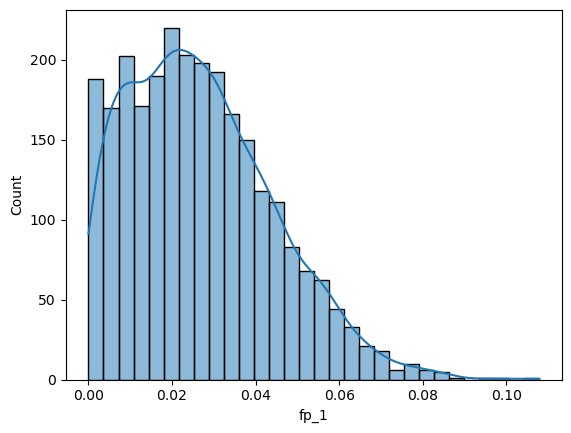

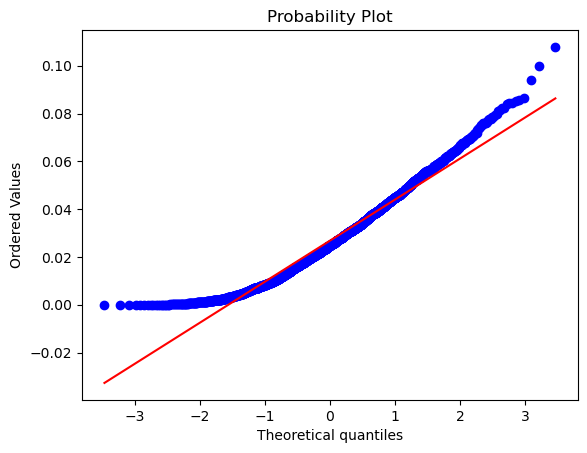

In [15]:
# inspect the second latent feature
feature = df_latent['fp_1']
# histogram
sns.histplot(feature, kde=True, bins=30)
plt.show()
# Q-Q plot
stats.probplot(feature, dist="norm", plot=plt)
plt.show()

In [16]:
print(df_latent['fp_0'].skew(axis=0, skipna=True))
print(df_latent['fp_1'].skew())

0.0
0.6589911955109164


In [17]:
def detect_outliers(df, feature):
    zscores = (df[feature] - df[feature].mean())/df[feature].std(ddof=0)

    lower_outliers = df[zscores < -3]
    upper_outliers = df[zscores > 3]

    lower_percent = len(lower_outliers) / len(df) * 100
    upper_percent = len(upper_outliers) / len(df) * 100

    return lower_percent, upper_percent

In [18]:
lower_percent, upper_percent = detect_outliers(df_latent, 'fp_0')
print(lower_percent, upper_percent)
lower_percent, upper_percent = detect_outliers(df_latent, 'fp_1')
print(lower_percent, upper_percent)

0.0 0.0
0.0 0.5683971201212581


Add latent fingerprint descriptors in a single column and scale them

In [19]:
df_latent['latent_fp'] = [np.array(df_latent.iloc[x, np.where(['fp_' in col for col in df_latent.columns])[0]]) for x in range(df_latent.shape[0])]
df_latent.head()

,Structure,fp_0,fp_1,fp_2,fp_3,fp_4,fp_5,fp_6,fp_7,fp_8,fp_9,fp_10,fp_11,fp_12,fp_13,fp_14,fp_15,fp_16,fp_17,fp_18,fp_19,fp_20,fp_21,fp_22,fp_23,fp_24,fp_25,fp_26,fp_27,fp_28,fp_29,fp_30,fp_31,fp_32,fp_33,fp_34,fp_35,fp_36,fp_37,fp_38,fp_39,fp_40,fp_41,fp_42,fp_43,fp_44,fp_45,fp_46,fp_47,fp_48,fp_49,fp_50,fp_51,fp_52,fp_53,fp_54,fp_55,fp_56,fp_57,fp_58,fp_59,fp_60,fp_61,fp_62,fp_63,fp_64,fp_65,fp_66,fp_67,fp_68,fp_69,fp_70,fp_71,fp_72,fp_73,fp_74,fp_75,fp_76,fp_77,fp_78,fp_79,fp_80,fp_81,fp_82,fp_83,fp_84,fp_85,fp_86,fp_87,fp_88,fp_89,fp_90,fp_91,fp_92,fp_93,fp_94,fp_95,fp_96,fp_97,fp_98,fp_99,fp_100,fp_101,fp_102,fp_103,fp_104,fp_105,fp_106,fp_107,fp_108,fp_109,fp_110,fp_111,fp_112,fp_113,fp_114,fp_115,fp_116,fp_117,fp_118,fp_119,fp_120,fp_121,fp_122,fp_123,fp_124,fp_125,fp_126,fp_127,fp_128,fp_129,fp_130,fp_131,fp_132,fp_133,fp_134,fp_135,fp_136,fp_137,fp_138,fp_139,fp_140,fp_141,fp_142,fp_143,fp_144,fp_145,fp_146,fp_147,fp_148,fp_149,fp_150,fp_151,fp_152,fp_153,fp_154,fp_155,fp_156,fp_157,fp_158,fp_159,fp_160,fp_161,fp_162,fp_163,fp_164,fp_165,fp_166,fp_167,fp_168,fp_169,fp_170,fp_171,fp_172,fp_173,fp_174,fp_175,fp_176,fp_177,fp_178,fp_179,fp_180,fp_181,fp_182,fp_183,fp_184,fp_185,fp_186,fp_187,fp_188,fp_189,fp_190,fp_191,fp_192,fp_193,fp_194,fp_195,fp_196,fp_197,fp_198,fp_199,fp_200,fp_201,fp_202,fp_203,fp_204,fp_205,fp_206,fp_207,fp_208,fp_209,fp_210,fp_211,fp_212,fp_213,fp_214,fp_215,fp_216,fp_217,fp_218,fp_219,fp_220,fp_221,fp_222,fp_223,fp_224,fp_225,fp_226,fp_227,fp_228,fp_229,fp_230,fp_231,fp_232,fp_233,fp_234,fp_235,fp_236,fp_237,fp_238,fp_239,fp_240,fp_241,fp_242,fp_243,fp_244,fp_245,fp_246,fp_247,fp_248,fp_249,fp_250,fp_251,fp_252,fp_253,fp_254,fp_255,fp_256,fp_257,fp_258,fp_259,fp_260,fp_261,fp_262,fp_263,fp_264,fp_265,fp_266,fp_267,fp_268,fp_269,fp_270,fp_271,fp_272,fp_273,fp_274,fp_275,fp_276,fp_277,fp_278,fp_279,fp_280,fp_281,fp_282,fp_283,fp_284,fp_285,fp_286,fp_287,fp_288,fp_289,fp_290,fp_291,fp_292,fp_293,fp_294,fp_295,fp_296,fp_297,fp_298,fp_299,latent_fp
0,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,0.0,0.022473,0.347611,0.048903,0.000646,0.022884,0.028259,0.037229,0.0,0.000000,0.014828,0.009977,0.041324,0.000139,0.007389,0.117769,0.196595,0.0,0.225198,0.095292,0.069374,0.143737,0.044455,0.010242,0.007673,0.038757,0.025289,0.102052,0.010394,0.002329,0.212633,0.079810,0.0,0.0,0.000000,0.000000,0.008273,0.241815,0.002917,0.171164,0.015563,0.131039,0.033214,0.0,0.0,0.0,0.029910,0.246105,0.000000,0.239741,0.005506,0.0,0.000305,0.0008,0.000000,0.180058,0.005665,0.214552,0.005076,0.004781,0.010475,0.005282,0.0,0.005574,0.127576,0.022550,0.006638,0.000000,0.050207,0.013349,0.000000,0.0,0.000000,0.0,0.000898,0.000000,0.0,0.212196,0.010130,0.267572,0.000000,0.124251,0.064367,0.0,0.0,0.002901,0.0,0.0,0.152697,0.021169,0.0,0.287879,0.037817,0.032448,0.0,0.0,0.000000,0.000000,0.140172,0.029623,0.063683,0.005660,0.001396,0.036072,0.212494,0.0,0.160597,0.002201,0.010938,0.217346,0.000000,0.222903,0.122754,0.045966,0.288143,0.284558,0.0,0.0,0.005403,0.003943,0.000000,0.188143,0.000000,0.149727,0.000000,0.000000,0.0,0.137230,0.069331,0.003933,0.039557,0.084335,0.176203,0.040613,0.0,0.007487,0.010127,0.143363,0.000000,0.009778,0.108469,0.001859,0.035543,0.047316,0.098089,0.001333,0.013507,0.085351,0.0,0.0,0.0,0.0,0.035644,0.221539,0.007874,0.061820,0.018984,0.048519,0.056822,0.006210,0.010594,0.056524,0.222332,0.172845,0.000000,0.050245,0.182276,0.0,0.014043,0.117512,0.000000,0.143289,0.121623,0.187593,0.17447,0.0,0.0,0.202170,0.012470,0.211305,0.0,0.0,0.173455,0.001942,0.021481,0.0,0.0,0.073686,0.211951,0.201260,0.005674,0.004129,0.0,0.002826,0.025151,0.010395,0.0,0.0,0.011943,0.145293,0.018114,0.0,0.011546,0.066758,0.024113,0.192240,0.0,0.0,0.002243,0.000000,0.060141,0.0,0.131601,0.047901,0.0,0.000000,0.000000,0.0,0.002167,0.000000,0.000000,0.0,0.142240,0.0,0.266963,0.019853,0.010586,0.023013,0.0,0.012706,0.079367,0.000000,0.147028,0.014567,0.006120,0.009695,0.102405,0.0,0.0,0.0,0.156147,0.0,0.030376,0.0,0.243909,

Merge latent representations

In [20]:
set(df.Structure) == set(df_latent.Structure)

True

In [21]:
print(df.shape)
print(df_latent.shape)
df = df.merge(df_latent[['Structure','latent_fp']], on=['Structure'])
print(df.shape)
df.head()

(2639, 6)
(2639, 302)
(2639, 7)


,Id,Structure,MDCK-MDR1_LogER,which_set,predicted MDCK-MDR1_LogER,variance MDCK-MDR1_LogER,latent_fp
0,Mol1,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,1.493167,TRAIN,1.246462,0.003577,"[0.0, 0.022473155, 0.34761134, 0.048902925, 0...."
1,Mol2,CCOc1cc2nn(CCC(C)(C)O)cc2cc1NC(=O)c1cccc(C(F)F)n1,1.040780,TRAIN,0.729273,0.005464,"[0.0, 0.021714553, 0.24628879, 0.03748544, 0.0..."
2,Mol5,CC(C)(O)CCn1cc2cc(NC(=O)c3cccc(C(F)(F)F)n3)c(C...,1.010597,TRAIN,0.904649,0.015962,"[0.0, 0.023629129, 0.25944853, 0.044478755, 0...."
3,Mol6,CC#CC(=O)N[C@H]1CCCN(c2c(F)cc(C(N)=O)c3[nH]c(C...,0.860626,TRAIN,1.248326,0.001152,"[0.0, 0.044359025, 0.28665268, 0.06647696, 0.0..."
4,Mol10,CC(C)NC(=O)COc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3...,1.301829,TRAIN,1.059820,0.004739,"[0.0, 0.029427862, 0.32627147, 0.035782427, 0...."


Given that most of latent fingerprint features show a positively skewed distribution (which does not follow a Gaussian distribution) and have a significant percentage of outliers (more than 0.3% as determined from the Z-score detection method), we employed a Robust Scaler to perform feature transformation, rather than using a Standard Scaler.

In [22]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
scaler.fit(np.array([np.array(x) for x in df[df.which_set == 'TRAIN'].latent_fp]))
df['latent_fp_scaled'] = [list(i) for i in scaler.transform(np.array([np.array(x) for x in df.latent_fp]))]
df = df.drop(columns='latent_fp')
df.head()

,Id,Structure,MDCK-MDR1_LogER,which_set,predicted MDCK-MDR1_LogER,variance MDCK-MDR1_LogER,latent_fp_scaled
0,Mol1,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,1.493167,TRAIN,1.246462,0.003577,"[0.0, -0.10849704689404319, 2.281163748136307,..."
1,Mol2,CCOc1cc2nn(CCC(C)(C)O)cc2cc1NC(=O)c1cccc(C(F)F)n1,1.040780,TRAIN,0.729273,0.005464,"[0.0, -0.13810292100243984, 0.8271953552245832..."
2,Mol5,CC(C)(O)CCn1cc2cc(NC(=O)c3cccc(C(F)(F)F)n3)c(C...,1.010597,TRAIN,0.904649,0.015962,"[0.0, -0.06338298086656159, 1.0160362995053591..."
3,Mol6,CC#CC(=O)N[C@H]1CCCN(c2c(F)cc(C(N)=O)c3[nH]c(C...,0.860626,TRAIN,1.248326,0.001152,"[0.0, 0.7456403162723266, 1.4064131135120086, ..."
4,Mol10,CC(C)NC(=O)COc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3...,1.301829,TRAIN,1.059820,0.004739,"[0.0, 0.16292351342979552, 1.9749387618045862,..."


## Save final datasets

Save the generated UNIQUE input dataset for each endpoint into a separate CSV file.

In [23]:
for endpoint in ['MDCK-MDR1_LogER']:

    print(f'\n{endpoint}')
    df_endpoint = df[['Id', 'Structure', f'{endpoint}', f'predicted {endpoint}', f'variance {endpoint}', 'which_set', 'latent_fp_scaled']]
    df_endpoint.columns = ['Id', 'Structure', 'labels', 'predictions', 'variance', 'which_set', 'latent_fp_scaled']

    print(df_endpoint.shape)
    df_endpoint = df_endpoint.dropna()
    print(df_endpoint.shape)

    print(df_endpoint.which_set.value_counts())
    print(df_endpoint.which_set.value_counts()/df_endpoint.which_set.value_counts().sum() * 100)

    df_endpoint.to_csv(f'unique_input_data/{endpoint}_unique_input_data.csv')


MDCK-MDR1_LogER
(2639, 7)
(2639, 7)
which_set
TRAIN          1321
CALIBRATION     791
TEST            527
Name: count, dtype: int64
which_set
TRAIN          50.056840
CALIBRATION    29.973475
TEST           19.969685
Name: count, dtype: float64
